## ANN - IVF y HNSW con faiss

Se comparan dos índices de vecinos aproximados de una librería (**faiss**, de Meta) contra la búsqueda exacta por fuerza bruta, sobre un mismo subconjunto de los vectores TF-IDF de `a_tfidf`

- **IVF** (`IndexIVFFlat`): la misma idea del índice propio en Spark de `b`/`c`, ahora con la implementación de la librería

- **HNSW** (`IndexHNSWFlat`): un grafo de vecinos navegable

### Installs

In [ ]:
%pip install -q faiss-cpu "numpy<2"

### Imports

In [2]:
import os, socket, time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import faiss
from pyspark.sql import SparkSession, functions as F

%matplotlib inline
plt.rcParams.update({"figure.dpi": 100, "axes.grid": True, "grid.alpha": .3})
pd.set_option("display.max_colwidth", 80); pd.set_option("display.width", 200)

### Utilidades

- Constantes

In [3]:
proyecto = Path.cwd()
while not (proyecto / "docker-compose.yml").exists() and proyecto != proyecto.parent:
    proyecto = proyecto.parent
vectores_dir = proyecto / "03_ANN" / "temp" / "a_tfidf" / "vectores"
out_dir = proyecto / "03_ANN" / "temp" / "d_faiss"
out_dir.mkdir(parents=True, exist_ok=True)

N_SUB = 20_000             # vectores del subconjunto: densos float32 de 4,096 dims = 330 MB por copia, y cada índice guarda la suya
N_CONSULTAS = 1_000        # consultas tomadas del subconjunto: 10,000 vecinos exactos para medir recall@K
EXP_NPROBE = [1, 2, 4, 8, 16, 32]         # listas revisadas por consulta en IVF
EXP_EF = [16, 32, 64, 128, 256]           # tamaño de la lista de candidatos en la búsqueda de HNSW
M_HNSW = 32                # conexiones por nodo: valor usual para vectores de alta dimensión (más M = mejor recall y más memoria)
EF_CONSTRUCCION = 200      # candidatos al construir el grafo: grafo de buena calidad sin alargar mucho la construcción
faiss.omp_set_num_threads(1)   # tiempo de respuesta con un solo hilo: comparable entre los tres métodos

- Funciones

Parámetros compartidos de `03_ANN/funciones.ipynb` (`K`, `SEED`, `NUM_FEATURES`)

In [4]:
ruta_funciones = str(proyecto / "03_ANN" / "funciones.ipynb")
%run $ruta_funciones

- Figuras y tablas

In [5]:
def mostrar_fig(nombre):
    plt.tight_layout()
    plt.savefig(fig_dir / f"{nombre}.png", dpi=150, bbox_inches="tight")
    plt.show()


def guardar_tabla(df, nombre):
    # parquet para el siguiente notebook + json para la página web
    sdf = spark.createDataFrame(df) if isinstance(df, pd.DataFrame) else df
    sdf.coalesce(1).write.mode("overwrite").parquet(str(tab_dir / nombre))
    sdf.toPandas().to_json(web_dir / f"{nombre}.json", orient="records", force_ascii=False, date_format="iso", indent=1)
    return len(df) if isinstance(df, pd.DataFrame) else sdf.count()


def dirs_salida(out_dir):
    fig_dir, tab_dir, web_dir = out_dir / "figs", out_dir / "tablas", out_dir / "web"
    for d in (fig_dir, tab_dir, web_dir):
        d.mkdir(parents=True, exist_ok=True)
    return fig_dir, tab_dir, web_dir


fig_dir, tab_dir, web_dir = dirs_salida(out_dir)

- Spark

In [6]:
spark_master = os.environ.get("spark_master", "local[*]")

builder = (SparkSession.builder
           .appName("ann-faiss")
           .master(spark_master)
           .config("spark.driver.memory",   os.environ.get("SPARK_DRIVER_MEMORY", "4g"))
           .config("spark.executor.memory", os.environ.get("SPARK_EXECUTOR_MEMORY", "4g"))
           .config("spark.sql.shuffle.partitions", "24")
           .config("spark.sql.autoBroadcastJoinThreshold", "-1")
           .config("spark.ui.showConsoleProgress", "false")
           .config("spark.sql.session.timeZone", "America/Lima"))

if spark_master.startswith("spark://"):
    builder = (builder.config("spark.driver.host", socket.gethostname())
                      .config("spark.driver.bindAddress", "0.0.0.0"))

spark = builder.getOrCreate()
spark.sparkContext.setLogLevel("ERROR")

### Verificación del cluster

In [ ]:
sc = spark.sparkContext
estado = sc._jsc.sc().getExecutorMemoryStatus()
print(f"Master        : {sc.master}")
print(f"Executors     : {estado.size() - 1}")
print(f"Cores totales : {sc.defaultParallelism}")
print(f"Memoria driver: {sc._jvm.java.lang.Runtime.getRuntime().maxMemory() / 1024**3:.1f} GB")
print("UI del job    : http://localhost:4040")

---
### HNSW: cómo funciona

- **Grafo de vecinos:** cada vector es un nodo conectado con hasta `M` vecinos cercanos. Para buscar, se parte de un nodo y se avanza siempre al vecino más cercano a la consulta (búsqueda voraz)

- **Jerarquía:** hay varias capas. Las de arriba tienen pocos nodos y enlaces largos, que acercan rápido a la zona de la consulta; la de abajo tiene todos los nodos y enlaces cortos, para afinar. Es la idea de una *skip list* llevada a grafos

- **Parámetros:** `M` (conexiones por nodo), `efConstruction` (candidatos al construir) y `efSearch` (candidatos al buscar: más grande = más recall y más tiempo)

| | IVF | HNSW |
|---|---|---|
| Estructura | particiones (KMeans) + listas | grafo jerárquico de vecinos |
| Entrenamiento | sí (KMeans) | no; se construye insertando |
| Perilla de búsqueda | `nprobe` | `efSearch` |
| Costo por consulta | ~ `nprobe / nlist` del índice | ~ log(n) saltos |
| Memoria extra | centroides | enlaces del grafo (~`2M` por vector) |
| Escala a muchos datos | bien, y se paraleliza por listas (por eso se usó en Spark) | muy rápido, pero el grafo vive en memoria de una máquina |

### 1. Subconjunto

- `N_SUB` vectores al azar de `temp/a_tfidf/vectores`, los mismos TF-IDF normalizados que usa el IVF de Spark

- Se pasan a matrices densas `float32` (faiss trabaja con vectores densos); con norma 1, el producto interno es el coseno

- Las `N_CONSULTAS` consultas salen del mismo subconjunto; en los tres métodos se busca `K + 1` y se descarta a la propia consulta

- **Tiempo de respuesta:** una consulta a la vez y con un hilo, como un buscador que atiende pedidos uno por uno

In [8]:
vectores = spark.read.parquet(str(vectores_dir))
n_total = vectores.count()
# se muestrea 20% de más y se corta en N_SUB: sample() no garantiza el tamaño exacto
filas = (vectores.sample(fraction=min(1.0, 1.2 * N_SUB / n_total), seed=SEED).select("ocid", "categoria", "idx", "val")
                 .limit(N_SUB).collect())
n = len(filas)
X = np.zeros((n, NUM_FEATURES), dtype="float32")
for i, r in enumerate(filas):
    X[i, r["idx"]] = r["val"]
ocids = np.array([r["ocid"] for r in filas])

rng = np.random.default_rng(SEED)
q_idx = rng.choice(n, size=N_CONSULTAS, replace=False)
Q = X[q_idx]
print(f"Subconjunto: {n:,} vectores x {X.shape[1]:,} dims ({X.nbytes / 1024**2:,.0f} MB) | consultas: {len(Q):,} | "
      f"normas {np.linalg.norm(X, axis=1).min():.4f}–{np.linalg.norm(X, axis=1).max():.4f}")

Subconjunto: 20,000 vectores x 4,096 dims (312 MB) | consultas: 1,000 | normas 1.0000–1.0000


- Auxiliar

In [9]:
def buscar(index, Q, k=K):
    # una consulta a la vez; busca k+1 y quita a la propia consulta. Devuelve ids, segundos y ms por consulta
    I = np.empty((len(Q), k + 1), dtype="int64")
    t0 = time.time()
    for j in range(len(Q)):
        I[j] = index.search(Q[j:j + 1], k + 1)[1][0]
    seg = time.time() - t0
    I = np.array([[x for x in fila if x != q][:k] for fila, q in zip(I, q_idx)])
    return I, seg, 1000 * seg / len(Q)

def recall_at_k(I, gt):
    return np.mean([len(set(a) & set(b)) / len(b) for a, b in zip(I, gt)])

### 2. Fuerza bruta exacta

`IndexFlatIP` compara cada consulta contra los `N_SUB` vectores: es la verdad para medir el recall

In [10]:
t0 = time.time()
flat = faiss.IndexFlatIP(X.shape[1]); flat.add(X)
seg_build_flat = time.time() - t0
GT, seg_flat, ms_flat = buscar(flat, Q)
print(f"Fuerza bruta: {N_CONSULTAS:,} consultas en {seg_flat:.2f} s ({ms_flat:.2f} ms por consulta)")

# referencia: las 1,000 consultas juntas en un solo lote, con todos los hilos
faiss.omp_set_num_threads(os.cpu_count())
t0 = time.time(); flat.search(Q, K + 1); seg_lote = time.time() - t0
faiss.omp_set_num_threads(1)
print(f"En un solo lote con {os.cpu_count()} hilos: {seg_lote:.2f} s ({1000 * seg_lote / N_CONSULTAS:.3f} ms por consulta)")

Fuerza bruta: 1,000 consultas en 6.57 s (6.57 ms por consulta)
En un solo lote con 8 hilos: 0.11 s (0.106 ms por consulta)


### 3. IVF (faiss)

- `nlist = √N_SUB` (≈ 141 listas de ~141 vectores): la regla usual, que equilibra comparar contra los centroides y contra los vectores de las listas

In [11]:
NLIST_F = int(round(np.sqrt(n)))   # regla √n: ~141 listas de ~141 vectores
t0 = time.time()
cuantizador = faiss.IndexFlatIP(X.shape[1])
ivf = faiss.IndexIVFFlat(cuantizador, X.shape[1], NLIST_F, faiss.METRIC_INNER_PRODUCT)
ivf.train(X); ivf.add(X)
seg_build_ivf = time.time() - t0
print(f"IVF: nlist = {NLIST_F} | entrenamiento + carga: {seg_build_ivf:.1f} s")

filas = []
for p_ in EXP_NPROBE:
    ivf.nprobe = p_
    I, seg, ms = buscar(ivf, Q)
    filas.append({"nprobe": p_, "frac_listas": round(p_ / NLIST_F, 3), "recall_at_k": round(recall_at_k(I, GT), 4), "ms_por_consulta": round(ms, 3)})
tabla_ivf = pd.DataFrame(filas)
tabla_ivf

IVF: nlist = 141 | entrenamiento + carga: 0.5 s


,nprobe,frac_listas,recall_at_k,ms_por_consulta
0,1,0.007,0.4844,0.139
1,2,0.014,0.5862,0.181
2,4,0.028,0.6644,0.298
3,8,0.057,0.7360,0.522
4,16,0.113,0.8128,0.947
5,32,0.227,0.8923,1.746


- El entrenamiento es casi instantáneo (0.5 s para 141 listas), pero el recall crece despacio: 0.48 con 1 lista, 0.74 con 8 y 0.89 con 32

- Con 32 listas (23% del índice) responde en 1.75 ms, 3.8x más rápido que la fuerza bruta

- Los vectores TF-IDF son dispersos y de alta dimensión: los vecinos de un proceso quedan repartidos en muchas listas, así que IVF necesita revisar bastante para no perderlos

### 4. HNSW (faiss)

In [12]:
t0 = time.time()
hnsw = faiss.IndexHNSWFlat(X.shape[1], M_HNSW, faiss.METRIC_INNER_PRODUCT)
hnsw.hnsw.efConstruction = EF_CONSTRUCCION
hnsw.add(X)
seg_build_hnsw = time.time() - t0
print(f"HNSW: M = {M_HNSW}, efConstruction = {EF_CONSTRUCCION} | construcción: {seg_build_hnsw:.1f} s")

filas = []
for ef in EXP_EF:
    hnsw.hnsw.efSearch = ef
    I, seg, ms = buscar(hnsw, Q)
    filas.append({"efSearch": ef, "recall_at_k": round(recall_at_k(I, GT), 4), "ms_por_consulta": round(ms, 3)})
tabla_hnsw = pd.DataFrame(filas)
tabla_hnsw

HNSW: M = 32, efConstruction = 200 | construcción: 44.5 s


,efSearch,recall_at_k,ms_por_consulta
0,16,0.9799,0.315
1,32,0.9820,0.523
2,64,0.9846,0.918
3,128,0.9856,1.722
4,256,0.9865,3.046


- Con `efSearch = 16` ya encuentra el 98% de los vecinos exactos en 0.32 ms por consulta, 21x más rápido que la fuerza bruta

- Subir `efSearch` casi no mejora el recall (0.980 → 0.987 con 256) y multiplica el tiempo por 10

- El costo está en la construcción: 44.5 s para 20k vectores, frente a 0.5 s del IVF; los enlaces del grafo apenas suman ~5 MB a los 312 MB de vectores

### 5. Comparación

In [13]:
mb_vec = X.nbytes / 1024**2
comparacion = pd.DataFrame([
    {"metodo": "fuerza bruta", "config": "exacto", "recall_at_k": 1.0, "ms_por_consulta": round(ms_flat, 3),
     "seg_construccion": round(seg_build_flat, 1), "memoria_mb": round(mb_vec, 0)},
    *[{"metodo": "IVF", "config": f"nprobe={r.nprobe}", "recall_at_k": r.recall_at_k, "ms_por_consulta": r.ms_por_consulta,
       "seg_construccion": round(seg_build_ivf, 1), "memoria_mb": round(mb_vec + NLIST_F * X.shape[1] * 4 / 1024**2, 0)} for r in tabla_ivf.itertuples()],
    *[{"metodo": "HNSW", "config": f"efSearch={r.efSearch}", "recall_at_k": r.recall_at_k, "ms_por_consulta": r.ms_por_consulta,
       "seg_construccion": round(seg_build_hnsw, 1), "memoria_mb": round(mb_vec + n * 2 * M_HNSW * 4 / 1024**2, 0)} for r in tabla_hnsw.itertuples()],
])
comparacion["aceleracion_vs_exacto"] = (ms_flat / comparacion["ms_por_consulta"]).round(1)
comparacion

,metodo,config,recall_at_k,ms_por_consulta,seg_construccion,memoria_mb,aceleracion_vs_exacto
0,fuerza bruta,exacto,1.0000,6.574,0.0,312.0,1.0
1,IVF,nprobe=1,0.4844,0.139,0.5,315.0,47.3
2,IVF,nprobe=2,0.5862,0.181,0.5,315.0,36.3
3,IVF,nprobe=4,0.6644,0.298,0.5,315.0,22.1
4,IVF,nprobe=8,0.7360,0.522,0.5,315.0,12.6
5,IVF,nprobe=16,0.8128,0.947,0.5,315.0,6.9
6,IVF,nprobe=32,0.8923,1.746,0.5,315.0,3.8
7,HNSW,efSearch=16,0.9799,0.315,44.5,317.0,20.9
8,HNSW,efSearch=32,0.9820,0.523,44.5,317.0,12.6
9,HNSW,efSearch=64,0.9846,0.918,44.5,317.0,7.2


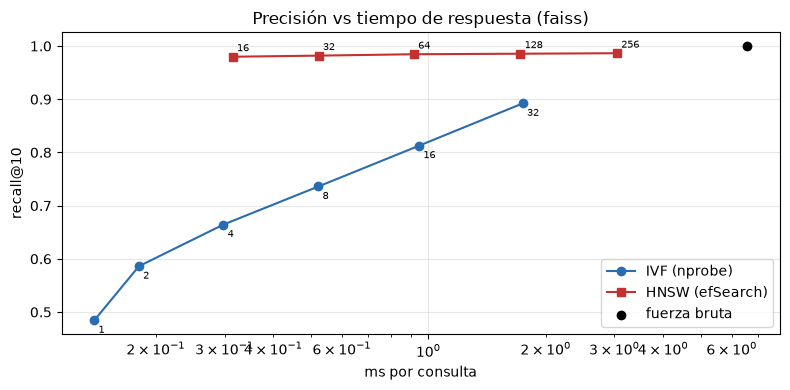

In [14]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(tabla_ivf["ms_por_consulta"], tabla_ivf["recall_at_k"], marker="o", color="#2b6cb0", label="IVF (nprobe)")
for r in tabla_ivf.itertuples():
    ax.annotate(f"{r.nprobe}", (r.ms_por_consulta, r.recall_at_k), fontsize=7, xytext=(3, -9), textcoords="offset points")
ax.plot(tabla_hnsw["ms_por_consulta"], tabla_hnsw["recall_at_k"], marker="s", color="#c53030", label="HNSW (efSearch)")
for r in tabla_hnsw.itertuples():
    ax.annotate(f"{r.efSearch}", (r.ms_por_consulta, r.recall_at_k), fontsize=7, xytext=(3, 4), textcoords="offset points")
ax.scatter([ms_flat], [1.0], color="black", zorder=3, label="fuerza bruta")
ax.set_xscale("log"); ax.set_xlabel("ms por consulta"); ax.set_ylabel(f"recall@{K}")
ax.set_title("Precisión vs tiempo de respuesta (faiss)"); ax.legend()
mostrar_fig("recall_vs_tiempo")

- **HNSW domina:** para cualquier tiempo de respuesta tiene más recall que IVF. Con 0.3 ms, HNSW llega a 0.98 e IVF a 0.66

- **IVF solo es preferible si importa construir rápido** (0.5 s vs 44.5 s) o si el índice debe repartirse en varias máquinas: por eso se usó en Spark para los 236k procesos (`b`, `c`), donde el grafo de HNSW no se puede distribuir

- **La fuerza bruta en lote no es comparable:** con las 1,000 consultas juntas y 8 hilos tarda 0.11 ms por consulta, porque el producto de matrices aprovecha todo el procesador. Los índices ANN ganan cuando las consultas llegan una por una o cuando los datos crecen: la fuerza bruta escala con N, HNSW con log N

- Configuraciones recomendadas: HNSW con `efSearch = 16`; IVF con `nprobe = 16–32` si se usa

### 6. Escritura de resultados

Tablas en `temp/d_faiss/tablas` (parquet) y `web/` (json)

In [15]:
tablas = {"ivf_nprobe": tabla_ivf, "hnsw_efsearch": tabla_hnsw, "comparacion": comparacion}
escritos = {nombre: guardar_tabla(df, nombre) for nombre, df in tablas.items()}
print(f"Escrito en temp/d_faiss/: {', '.join(escritos)}")

Escrito en temp/d_faiss/: ivf_nprobe, hnsw_efsearch, comparacion


#### a. Verificación

In [16]:
for nombre, n in escritos.items():
    leido = spark.read.parquet(str(tab_dir / nombre)).count()
    assert leido == n, f"{nombre}: esperaba {n}, leí {leido}"
    assert (web_dir / f"{nombre}.json").exists(), f"falta web/{nombre}.json"

figs = sorted(p.stem for p in fig_dir.glob("*.png"))
print(f"OK: {len(escritos)} tablas (parquet + json) | {len(figs)} figuras: {', '.join(figs)}")

OK: 3 tablas (parquet + json) | 1 figuras: recall_vs_tiempo


---
### 7. Cerrar sesión

In [17]:
spark.stop()